# Wind Turbine Underperformance Detection

**Goal:** Flag periods when a wind turbine is producing well below what it should be, given the wind conditions — a classification problem, not a forecasting one.

**Data:** SCADA data from a wind turbine in Turkey, 10-minute intervals across 2018 — wind speed, wind direction, actual power output, and the manufacturer's theoretical power curve. Source: [Wind Turbine SCADA Dataset (Kaggle)](https://www.kaggle.com/berkerisen/wind-turbine-scada-dataset), via [coderkhongodo/data_wind](https://github.com/coderkhongodo/data_wind).

**Why it matters:** Every wind turbine has a manufacturer-specified power curve — how much power it *should* generate at a given wind speed. When actual output falls well below that curve, it's often a sign of a fault, icing, yaw misalignment, or curtailment — catching it early matters for maintenance and revenue.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

df = pd.read_csv("T1.csv")
df.columns = ["datetime", "active_power_kw", "wind_speed", "theoretical_power_kwh", "wind_direction"]
df["datetime"] = pd.to_datetime(df["datetime"], format="%d %m %Y %H:%M")
df = df.dropna()
df.head()

             datetime  active_power_kw  wind_speed  theoretical_power_kwh  wind_direction
0 2018-01-01 00:00:00       380.047791    5.311336             416.328908      259.994904
1 2018-01-01 00:10:00       453.769196    5.672167             519.917511      268.641113
2 2018-01-01 00:20:00       306.376587    5.216037             390.900016      272.564789
3 2018-01-01 00:30:00       419.645905    5.659674             516.127569      271.258087
4 2018-01-01 00:40:00       380.650696    5.577941             491.702972      265.674286

## Defining "underperforming"

Only periods above cut-in wind speed (3 m/s) are considered — below that, a turbine isn't expected to produce anyway. Efficiency is actual output divided by the theoretical power curve value at that wind speed; anything under 60% efficiency is labeled underperforming.

In [ ]:
df = df[df["wind_speed"] > 3.0].copy()
df["efficiency"] = df["active_power_kw"] / df["theoretical_power_kwh"].replace(0, np.nan)
df = df.dropna(subset=["efficiency"])
df["underperforming"] = (df["efficiency"] < 0.6).astype(int)

print(f"Total usable records: {len(df):,}")
print(f"Underperforming rate: {df['underperforming'].mean()*100:.1f}%")

Total usable records: 42,781
Underperforming rate: 12.9%

## Model: Random Forest Classifier

Using only wind speed and wind direction — the conditions the turbine is operating in — to predict whether it's underperforming. Classes are imbalanced (~13% positive), so `class_weight="balanced"` is used.

In [ ]:
feature_cols = ["wind_speed", "wind_direction"]
X, y = df[feature_cols], df["underperforming"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=250, max_depth=8, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
prob = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, pred):.3f}")
print(f"Precision: {precision_score(y_test, pred):.3f}")
print(f"Recall:    {recall_score(y_test, pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, prob):.3f}")

Accuracy:  0.837
Precision: 0.419
Recall:    0.673
F1 Score:  0.516
ROC AUC:   0.852

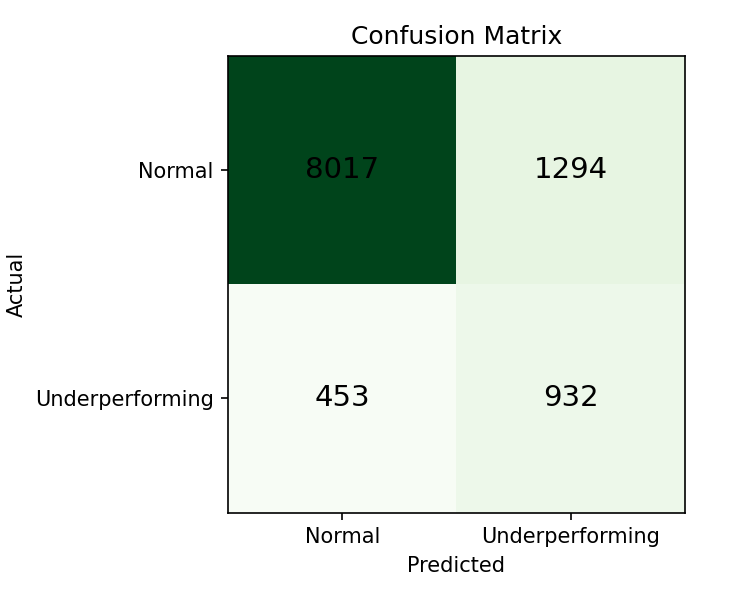

In [ ]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Greens")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=14)
plt.xticks([0,1], ["Normal","Underperforming"]); plt.yticks([0,1], ["Normal","Underperforming"])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.tight_layout(); plt.show()

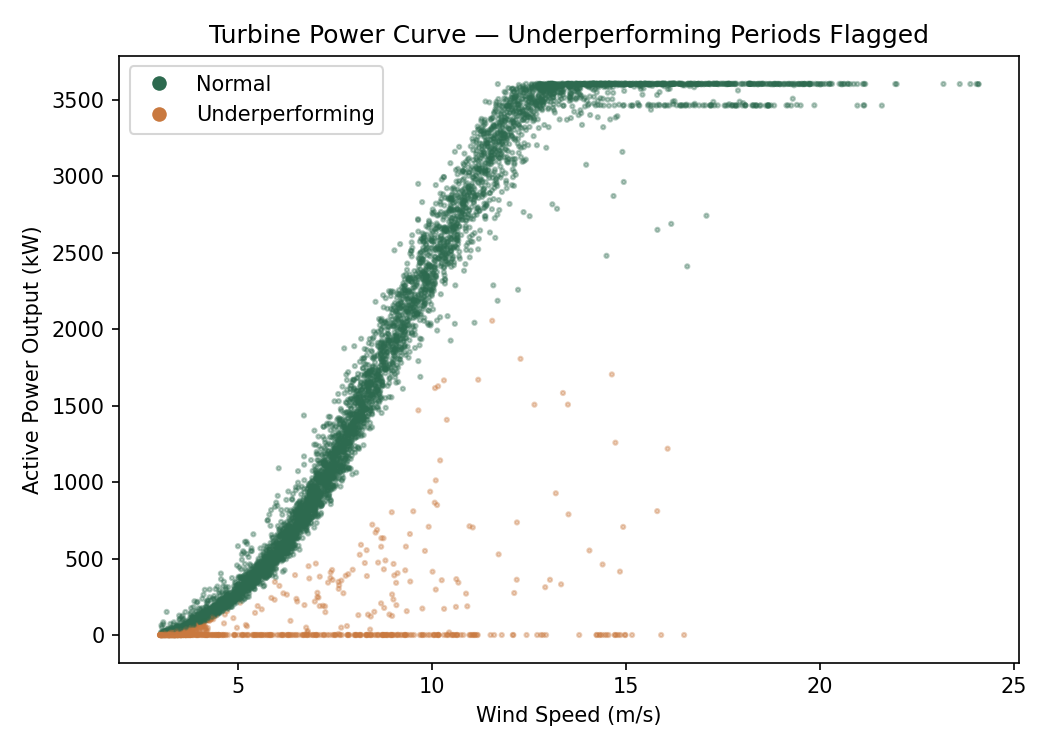

In [ ]:
sample = df.sample(6000, random_state=1)
plt.figure(figsize=(7,5))
plt.scatter(sample["wind_speed"], sample["active_power_kw"], s=4, alpha=0.35,
            c=sample["underperforming"].map({0:"#2D6A4F",1:"#C9793F"}))
plt.xlabel("Wind Speed (m/s)"); plt.ylabel("Active Power Output (kW)")
plt.title("Turbine Power Curve — Underperforming Periods Flagged")
plt.tight_layout(); plt.show()

## Takeaways

- The model catches **67% of true underperformance events** (recall) with a ROC AUC of **0.85**, using nothing but wind speed and direction.
- Precision is more modest (0.42) — about 6 in 10 flagged periods are false alarms. For a maintenance-alerting use case that trade-off is usually the right one: missing a real fault is costlier than double-checking a false alarm.
- Wind speed dominates the model (75% of feature importance) — makes sense, since it's the main driver of the power curve. Wind direction adds a smaller but real signal, likely picking up yaw misalignment effects.
- Next step: add temperature and gearbox/rotor telemetry (available in richer SCADA datasets) to separate different fault types rather than one blanket "underperforming" label.